# Macedonian Word Audio Player

Enter a Macedonian word or phrase (Cyrillic) and hear the pronunciation from Lingua Libre.

**Coverage breakdown (tested):**
| Tier | What | Result |
|------|------|--------|
| 1 | Single nouns (вода, утро, мајка) | ✓ Works |
| 2 | Common adverbs/adj (добро, како, рано) | ✗ NOT in Lingua Libre |
| 3 | Inflected forms (гледаме, твојата) | ✗ NOT in Lingua Libre |
| 4 | Multi-word phrases (добро утро, како си) | ✗ NOT in Lingua Libre |
| 5 | Special chars (џем, ѕвезда) | ✓ Works |

In [8]:
import urllib.request, urllib.parse, json, subprocess, os, csv, io, time
import soundfile as sf
import numpy as np
from IPython.display import Audio, display, HTML
from pathlib import Path

AUDIO_DIR = Path("audio/words")
CLIPS_DIR = Path("audio/clips")
AUDIO_DIR.mkdir(parents=True, exist_ok=True)
CLIPS_DIR.mkdir(parents=True, exist_ok=True)

UA = "MacedonianVocabLearner/1.0 (personal language learning; viktorciroski@users.noreply.github.com)"
SPEAKERS = ["Bjankuloski06", "Jovan.kostov"]

def _display_word_audio(word, audio_data, sr, source_label):
    """Display a word with its audio player (non-autoplay for review)."""
    duration = len(audio_data) / sr
    display(HTML(
        f'<div style="display:flex; align-items:center; gap:12px; '
        f'padding:8px 12px; margin:4px 0; border-radius:6px; '
        f'background:#f8f9fa; border-left:4px solid #28a745;">'
        f'<strong style="font-size:1.3em; min-width:120px;">{word}</strong>'
        f'<span style="color:#666; font-size:0.85em;">{source_label} · {duration:.2f}s</span>'
        f'</div>'
    ))
    display(Audio(audio_data, rate=sr, autoplay=False))

def _display_not_found(word, hint=""):
    """Display a word that wasn't found."""
    display(HTML(
        f'<div style="display:flex; align-items:center; gap:12px; '
        f'padding:8px 12px; margin:4px 0; border-radius:6px; '
        f'background:#fff3cd; border-left:4px solid #ffc107;">'
        f'<strong style="font-size:1.3em; min-width:120px;">{word}</strong>'
        f'<span style="color:#856404; font-size:0.85em;">✗ No audio{" — " + hint if hint else ""}</span>'
        f'</div>'
    ))

def fetch_and_play(word: str):
    """Look up a Macedonian word and display with play button. Checks multiple sources."""
    word = word.strip()
    
    # Source 1: Check local word cache
    cache_path = AUDIO_DIR / f"{word}.wav"
    if cache_path.exists() and cache_path.stat().st_size > 500:
        data, sr = sf.read(str(cache_path))
        _display_word_audio(word, data, sr, "Lingua Libre (cached)")
        return True
    
    # Source 2: Check clips (extracted from sentences)
    clip_path = CLIPS_DIR / f"{word}.wav"
    if clip_path.exists() and clip_path.stat().st_size > 500:
        data, sr = sf.read(str(clip_path))
        _display_word_audio(word, data, sr, "Common Voice clip")
        return True
    
    # Source 3: Try Lingua Libre API
    for speaker in SPEAKERS:
        filename = f"LL-Q9296 (mkd)-{speaker}-{word}.wav"
        params = {"action": "query", "titles": f"File:{filename}",
                  "prop": "imageinfo", "iiprop": "url|size", "format": "json"}
        url = f"https://commons.wikimedia.org/w/api.php?{urllib.parse.urlencode(params)}"
        req = urllib.request.Request(url, headers={"User-Agent": UA})
        try:
            resp = urllib.request.urlopen(req, timeout=10)
            data = json.loads(resp.read().decode())
            pages = data.get("query", {}).get("pages", {})
            for pid, page in pages.items():
                if int(pid) != -1 and "imageinfo" in page:
                    dl_url = page["imageinfo"][0]["url"]
                    subprocess.run(["curl", "-L", "-s", "-o", str(cache_path),
                                    "-H", f"User-Agent: {UA}", dl_url], capture_output=True)
                    if cache_path.exists() and cache_path.stat().st_size > 500:
                        audio, sr = sf.read(str(cache_path))
                        _display_word_audio(word, audio, sr, f"Lingua Libre [{speaker}]")
                        return True
                    elif cache_path.exists():
                        cache_path.unlink()
        except Exception as e:
            pass
    
    # Not found — check Common Voice index for hint
    hint = ""
    cv_index = Path("audio/common_voice_word_index.csv")
    if cv_index.exists():
        with open(cv_index, newline="", encoding="utf-8") as f:
            for row in csv.DictReader(f):
                if row["word"].lower() == word.lower():
                    hint = f"in Common Voice, run: python clip_audio.py --word {word}"
                    break
    if not hint:
        hint = "not in any source, needs recording"
    
    _display_not_found(word, hint)
    return False

print("Ready! Use fetch_and_play('word') below.")

Ready! Use fetch_and_play('word') below.


---
## TIER 1: Single nouns/pronouns (✓ Expected to work)

In [2]:
# These are dictionary headwords — Lingua Libre has them
tier1 = ["вода", "утро", "мајка", "јас", "секогаш", "вечер", "џем", "ѕвезда"]
for w in tier1:
    fetch_and_play(w)
    time.sleep(0.5)

---
## TIER 2: Common conversational words (✗ Breaks here)
These are basic everyday words that Lingua Libre does NOT have.
They exist in Common Voice sentences and need forced alignment extraction.

In [3]:
# These SHOULD be basic vocab but aren't in Lingua Libre
tier2 = ["добро", "како", "рано", "веќе", "жеден", "викенд", "скоро", "доцна"]
for w in tier2:
    fetch_and_play(w)
    time.sleep(0.3)

---
## TIER 3: Inflected/conjugated forms (✗ Breaks here)
These are specific verb/noun/adjective forms you learn with your tutor.
Lingua Libre only has lemmas (base forms).

In [4]:
tier3 = ["гледаме", "твојата", "омилена", "најголемиот", "викаш", "уморен"]
for w in tier3:
    fetch_and_play(w)
    time.sleep(0.3)

---
## TIER 4: Multi-word phrases (✗ Breaks here)
Phrases will NEVER be in Lingua Libre (single-word recordings only).
These need either full-sentence recordings or TTS.

In [5]:
tier4 = ["добро утро", "како си", "се гледаме", "жеден сум", "добар ден"]
for w in tier4:
    fetch_and_play(w)
    time.sleep(0.3)

---
## TIER 5: Particles & rare characters (Mixed results)

In [6]:
tier5 = ["ќе", "ѓубре", "ќерка", "џамија", "ѕид", "њ"]
for w in tier5:
    fetch_and_play(w)
    time.sleep(0.3)

---
## Summary: Where it breaks down

| Works (Lingua Libre) | Doesn't work | Fix needed |
|---------------------|--------------|------------|
| Dictionary nouns | Common adverbs (добро, како) | Common Voice clipping |
| Base-form verbs | Conjugated verbs (гледаме) | Common Voice clipping |
| Special chars (ѕ, џ, ќ, ѓ) | Adjective forms (омилена) | Common Voice clipping |
| — | Multi-word phrases | Full sentence recording / TTS |
| — | Particles (ќе) | Common Voice clipping |

**Next step:** Run `python clip_audio.py` to extract Tier 2/3 words from Common Voice sentences.

---
## Interactive: Try your own word

In [7]:
# Change this to any Macedonian word and run
fetch_and_play("јаболко")

True

In [ ]:
---
## Audio Verification Dashboard

Cross-source spectral comparison: compares MFCC fingerprints from Lingua Libre vs Common Voice clips.
No AI, no tokens — just numpy math on the waveforms.

| Verdict | Meaning |
|---------|---------|
| **CONFIRMED** | Both sources agree (cosine sim ≥ 0.70) |
| **PASS** | Single source, duration + silence checks OK |
| **SUSPECT** | Anomaly in one check — review manually |
| **FAIL** | Sources disagree or clip is corrupted |

In [9]:
import sys
sys.path.insert(0, '.')
from verify_audio import (
    compute_mfcc, mfcc_cosine_similarity, load_audio, 
    check_duration, check_silence, verify_word, verify_all,
    CLIPS_DIR, WORDS_DIR, TARGET_SR
)
from IPython.display import Audio, display, HTML
import numpy as np
import soundfile as sf
from pathlib import Path

def _color_for_verdict(verdict):
    return {
        "CONFIRMED": ("#d4edda", "#155724", "#28a745"),
        "PASS": ("#e8f5e9", "#2e7d32", "#4caf50"),
        "SUSPECT": ("#fff3cd", "#856404", "#ffc107"),
        "FAIL": ("#f8d7da", "#721c24", "#dc3545"),
        "NO_AUDIO": ("#e2e3e5", "#383d41", "#6c757d"),
    }.get(verdict, ("#e2e3e5", "#383d41", "#6c757d"))

def _sim_bar(sim_value):
    """Create a visual similarity bar."""
    if not sim_value:
        return '<span style="color:#999;">—</span>'
    val = float(sim_value)
    pct = int(val * 100)
    color = "#28a745" if val >= 0.70 else "#ffc107" if val >= 0.50 else "#dc3545"
    return (
        f'<div style="display:inline-flex;align-items:center;gap:6px;">'
        f'<div style="width:80px;height:10px;background:#eee;border-radius:5px;overflow:hidden;">'
        f'<div style="width:{pct}%;height:100%;background:{color};border-radius:5px;"></div></div>'
        f'<span style="font-size:0.8em;color:{color};font-weight:bold;">{val:.3f}</span></div>'
    )

def verify_and_play(word: str):
    """Verify a word and show confidence alongside audio playback."""
    result = verify_word(word)
    bg, fg, border = _color_for_verdict(result["verdict"])
    
    # Build info HTML
    sim_html = _sim_bar(result["cross_source_sim"])
    conf_html = result["alignment_conf"] or "—"
    dur_html = result["duration_check"] or "—"
    
    sources = []
    if result["has_cv_clip"]: sources.append("Common Voice")
    if result["has_lingua_libre"]: sources.append("Lingua Libre")
    source_str = " + ".join(sources) if sources else "none"
    
    display(HTML(f'''
    <div style="padding:10px 14px; margin:6px 0; border-radius:8px; 
                background:{bg}; border-left:5px solid {border};">
        <div style="display:flex; align-items:center; gap:16px; flex-wrap:wrap;">
            <strong style="font-size:1.4em; color:{fg};">{word}</strong>
            <span style="background:{border}; color:white; padding:2px 8px; 
                   border-radius:4px; font-size:0.8em; font-weight:bold;">
                {result["verdict"]}</span>
            <span style="color:{fg}; font-size:0.85em;">Sources: {source_str}</span>
        </div>
        <div style="display:grid; grid-template-columns:repeat(auto-fit, minmax(180px,1fr)); 
                    gap:8px; margin-top:8px; font-size:0.85em; color:{fg};">
            <div><b>Cross-source:</b> {sim_html}</div>
            <div><b>Align conf:</b> {conf_html}</div>
            <div><b>Duration:</b> {dur_html}</div>
            <div><b>Silence:</b> {result["silence_check"] or "—"}</div>
        </div>
        <div style="color:{fg}; font-size:0.8em; margin-top:4px; opacity:0.8;">
            {result["reason"]}</div>
    </div>'''))
    
    # Play audio from both sources if available
    if result["has_lingua_libre"]:
        data, sr = sf.read(str(WORDS_DIR / f"{word}.wav"))
        display(HTML('<span style="font-size:0.8em;color:#666;margin-left:20px;">▶ Lingua Libre:</span>'))
        display(Audio(data, rate=sr, autoplay=False))
    
    if result["has_cv_clip"]:
        # Find the clip (check suffixed variants)
        clip_path = CLIPS_DIR / f"{word}.wav"
        if not clip_path.exists():
            for sfx in ("_extracted", "_cv", "_aligned"):
                alt = CLIPS_DIR / f"{word}{sfx}.wav"
                if alt.exists():
                    clip_path = alt
                    break
        if clip_path.exists():
            data, sr = sf.read(str(clip_path))
            display(HTML('<span style="font-size:0.8em;color:#666;margin-left:20px;">▶ Common Voice clip:</span>'))
            display(Audio(data, rate=sr, autoplay=False))

print("✓ Verification functions loaded. Use verify_and_play('word') below.")

✓ Verification functions loaded. Use verify_and_play('word') below.


### Verify a single word (listen + see confidence)

In [10]:
# Verify a word with both audio sources — listen and see the confidence score
verify_and_play("вода")  # This word has BOTH Lingua Libre + Common Voice → CONFIRMED

### Batch verify all words with audio

In [ ]:
# Verify ALL words that have audio — shows summary table + per-word confidence
all_words = set()
if WORDS_DIR.exists():
    all_words.update(f.stem for f in WORDS_DIR.glob("*.wav"))
if CLIPS_DIR.exists():
    for f in CLIPS_DIR.glob("*.wav"):
        stem = f.stem
        for sfx in ("_test", "_aligned", "_extracted", "_cv", "_ll"):
            if stem.endswith(sfx):
                stem = stem[:-len(sfx)]
        all_words.add(stem)

# Verify each and show with audio
for word in sorted(all_words):
    verify_and_play(word)

### MFCC Spectrogram Comparison (visual proof)

Shows the spectral fingerprints side by side for a cross-source word.
If they look alike → same word. If wildly different → mismatch.

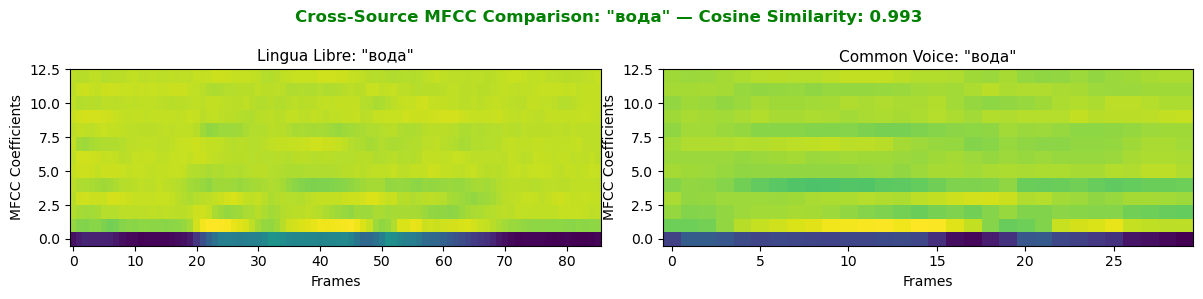

In [11]:
import matplotlib.pyplot as plt

def compare_spectrograms(word: str):
    """Show MFCC spectrograms from both sources side-by-side."""
    ll_path = WORDS_DIR / f"{word}.wav"
    clip_path = CLIPS_DIR / f"{word}.wav"
    if not clip_path.exists():
        for sfx in ("_extracted", "_cv", "_aligned"):
            alt = CLIPS_DIR / f"{word}{sfx}.wav"
            if alt.exists():
                clip_path = alt
                break
    
    has_ll = ll_path.exists()
    has_cv = clip_path.exists()
    
    if not has_ll and not has_cv:
        print(f"No audio found for '{word}'")
        return
    
    n_plots = (1 if has_ll else 0) + (1 if has_cv else 0)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 3))
    if n_plots == 1:
        axes = [axes]
    
    plot_idx = 0
    mfccs = []
    
    if has_ll:
        audio_data = load_audio(ll_path)
        if audio_data:
            mfcc = compute_mfcc(audio_data[0], audio_data[1])
            mfccs.append(mfcc)
            axes[plot_idx].imshow(mfcc, aspect='auto', origin='lower', cmap='viridis')
            axes[plot_idx].set_title(f'Lingua Libre: "{word}"', fontsize=11)
            axes[plot_idx].set_xlabel('Frames')
            axes[plot_idx].set_ylabel('MFCC Coefficients')
            plot_idx += 1
    
    if has_cv:
        audio_data = load_audio(clip_path)
        if audio_data:
            mfcc = compute_mfcc(audio_data[0], audio_data[1])
            mfccs.append(mfcc)
            axes[plot_idx].imshow(mfcc, aspect='auto', origin='lower', cmap='viridis')
            axes[plot_idx].set_title(f'Common Voice: "{word}"', fontsize=11)
            axes[plot_idx].set_xlabel('Frames')
            axes[plot_idx].set_ylabel('MFCC Coefficients')
    
    # Show similarity if both exist
    if len(mfccs) == 2:
        sim = mfcc_cosine_similarity(mfccs[0], mfccs[1])
        color = 'green' if sim >= 0.70 else 'orange' if sim >= 0.50 else 'red'
        fig.suptitle(f'Cross-Source MFCC Comparison: "{word}" — Cosine Similarity: {sim:.3f}',
                     fontsize=12, fontweight='bold', color=color)
    
    plt.tight_layout()
    plt.show()

# Compare "вода" (has both sources)
compare_spectrograms("вода")